# Comparacion de Resultados: Con Plan vs Sin Plan
Este notebook compara 2 archivos `generation_results_*.json` indicados manualmente por nombre (uno sin plan y otro con plan).

In [ ]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)

ROOT = Path('.')

# =====================
# COMPLETA AQUI LOS NOMBRES
# =====================
RUN_NOPLAN_FILENAME = 'PON_AQUI_TU_ARCHIVO_SIN_PLAN.json'
RUN_PLAN_FILENAME = 'PON_AQUI_TU_ARCHIVO_CON_PLAN.json'

RUN_NOPLAN_PATH = ROOT / RUN_NOPLAN_FILENAME
RUN_PLAN_PATH = ROOT / RUN_PLAN_FILENAME

if not RUN_NOPLAN_PATH.exists():
    raise FileNotFoundError(f'No existe el archivo sin plan: {RUN_NOPLAN_PATH}')
if not RUN_PLAN_PATH.exists():
    raise FileNotFoundError(f'No existe el archivo con plan: {RUN_PLAN_PATH}')

print(f'Sin plan: {RUN_NOPLAN_PATH}')
print(f'Con plan: {RUN_PLAN_PATH}')

Usando archivo: generation_results_20260326_132325.json


In [ ]:
def load_payload(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

payload_noplan = load_payload(RUN_NOPLAN_PATH)
payload_plan = load_payload(RUN_PLAN_PATH)

df_plan = pd.DataFrame(payload_plan['results']).copy()
df_noplan = pd.DataFrame(payload_noplan['results']).copy()

metrics = [
    'rouge1', 'rouge2', 'rougeL', 'bertscore_f1',
    'avg_time_per_sample', 'error_count', 'error_rate', 'samples_evaluated'
 ]

left_cols = ['model_name', 'params'] + [c for c in metrics if c in df_noplan.columns]
right_cols = ['model_name', 'params'] + [c for c in metrics if c in df_plan.columns]

df_compare = df_noplan[left_cols].merge(
    df_plan[right_cols],
    on='model_name',
    suffixes=('_sin_plan', '_con_plan')
)

for m in ['rouge1', 'rouge2', 'rougeL', 'bertscore_f1', 'avg_time_per_sample', 'error_rate']:
    a = f'{m}_con_plan'
    b = f'{m}_sin_plan'
    if a in df_compare.columns and b in df_compare.columns:
        df_compare[f'delta_{m}'] = df_compare[a] - df_compare[b]

cols_view = [
    'model_name',
    'rouge1_sin_plan', 'rouge1_con_plan', 'delta_rouge1',
    'rouge2_sin_plan', 'rouge2_con_plan', 'delta_rouge2',
    'rougeL_sin_plan', 'rougeL_con_plan', 'delta_rougeL',
    'bertscore_f1_sin_plan', 'bertscore_f1_con_plan', 'delta_bertscore_f1',
    'avg_time_per_sample_sin_plan', 'avg_time_per_sample_con_plan', 'delta_avg_time_per_sample'
 ]

compare_view = df_compare[[c for c in cols_view if c in df_compare.columns]]
compare_view.sort_values('delta_bertscore_f1', ascending=False).reset_index(drop=True)

,model_name,params,samples_evaluated,rouge1,rouge2,rougeL,bertscore_f1,avg_time_per_sample,error_count,error_rate
0,Qwen2.5-14B-Instruct,14B,100,0.8564,0.8041,0.8552,0.9770,44.8931,0,0.0
1,Qwen2.5-7B-Instruct,7B,100,0.8652,0.8008,0.8614,0.9755,1.7360,0,0.0
2,Phi-4,14B,100,0.8449,0.8025,0.8419,0.9671,40.1842,0,0.0
3,Llama-3.1-8B-Instruct,8B,100,0.7493,0.6785,0.7377,0.9645,13.6740,0,0.0
4,Mistral-7B-Instruct,7B,100,0.7018,0.6225,0.6906,0.9596,3.4460,0,0.0
5,Gemma-2-9B-it,9B,100,0.7208,0.6411,0.6992,0.9589,14.7167,0,0.0
6,Phi-3.5-mini-instruct,3.8B,100,0.6282,0.5234,0.6073,0.9494,2.3641,0,0.0
7,Llama-3.2-3B-Instruct,3B,100,0.6044,0.4945,0.5876,0.9463,1.8660,0,0.0
8,Zephyr-7B,7B,100,0.3332,0.2804,0.3157,0.9118,9.9574,0,0.0
9,Qwen2.5-3B-Instruct,3B,100,0.3253,0.2486,0.3135,0.8854,2.1196,0,0.0


## Ranking de mejora (con plan - sin plan)

In [ ]:
ranking = compare_view[[
    c for c in [
        'model_name',
        'delta_rouge1', 'delta_rouge2', 'delta_rougeL',
        'delta_bertscore_f1', 'delta_avg_time_per_sample'
    ] if c in compare_view.columns
]].copy()

ranking = ranking.sort_values('delta_bertscore_f1', ascending=False).reset_index(drop=True)
ranking

,model_name,rouge1,rouge2,rougeL,bertscore_f1
0,Qwen2.5-14B-Instruct,0.8564,0.8041,0.8552,0.9770
1,Qwen2.5-7B-Instruct,0.8652,0.8008,0.8614,0.9755
2,Phi-4,0.8449,0.8025,0.8419,0.9671
3,Llama-3.1-8B-Instruct,0.7493,0.6785,0.7377,0.9645
4,Mistral-7B-Instruct,0.7018,0.6225,0.6906,0.9596
5,Gemma-2-9B-it,0.7208,0.6411,0.6992,0.9589
6,Phi-3.5-mini-instruct,0.6282,0.5234,0.6073,0.9494
7,Llama-3.2-3B-Instruct,0.6044,0.4945,0.5876,0.9463
8,Zephyr-7B,0.3332,0.2804,0.3157,0.9118
9,Qwen2.5-3B-Instruct,0.3253,0.2486,0.3135,0.8854


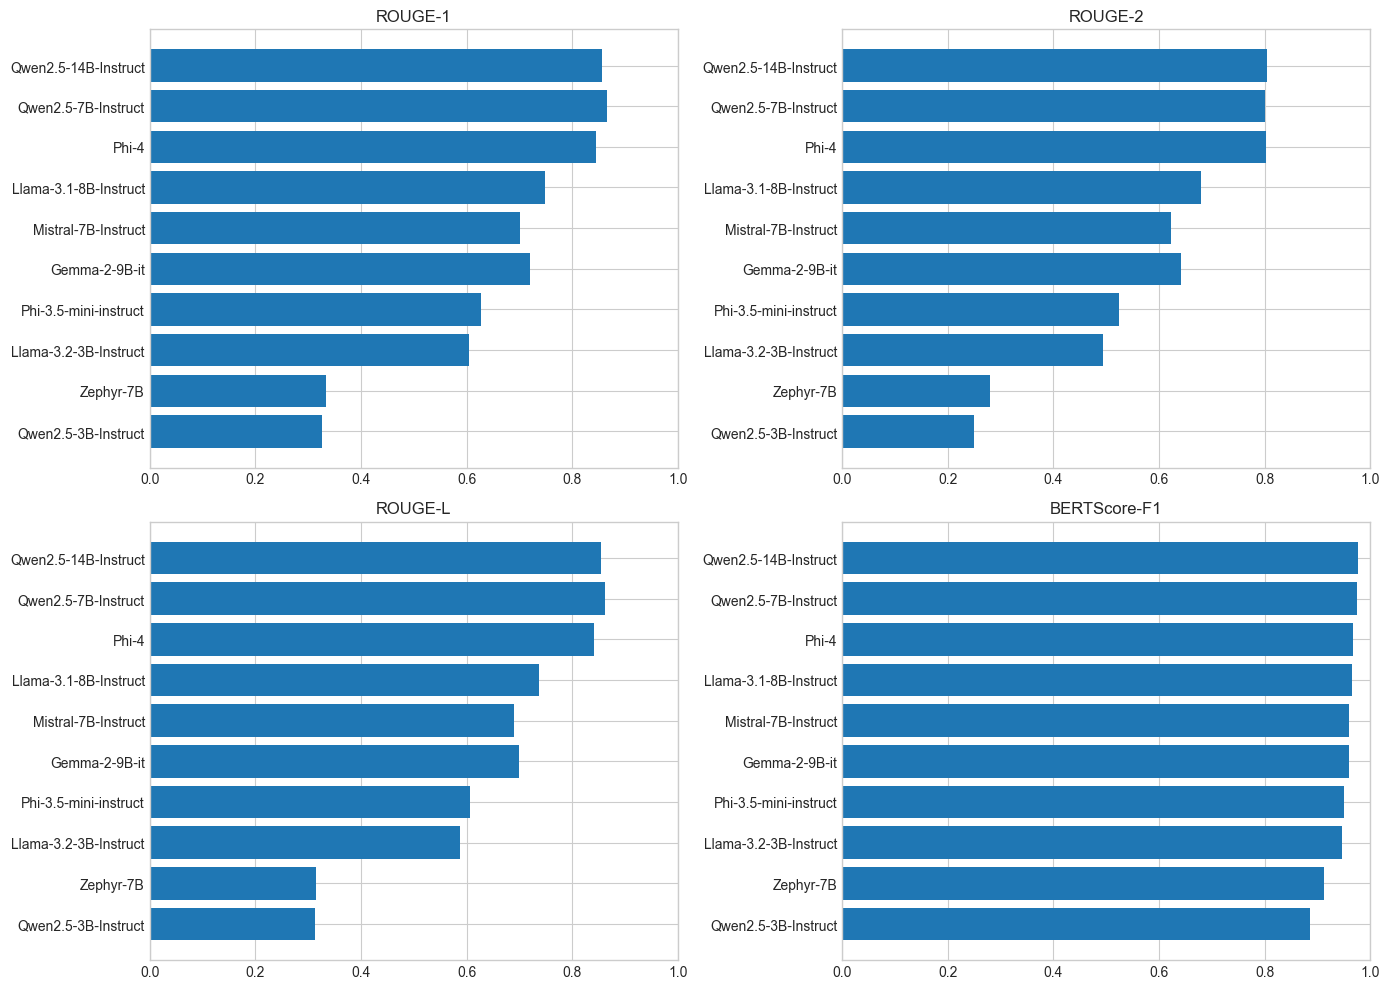

In [ ]:
plot_df = ranking.sort_values('delta_bertscore_f1', ascending=True).copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
delta_metrics = ['delta_rouge1', 'delta_rouge2', 'delta_rougeL', 'delta_bertscore_f1']
titles = ['Delta ROUGE-1', 'Delta ROUGE-2', 'Delta ROUGE-L', 'Delta BERTScore-F1']

for ax, metric, title in zip(axes.flatten(), delta_metrics, titles):
    if metric not in plot_df.columns:
        ax.set_visible(False)
        continue

    values = plot_df[metric].fillna(0)
    colors = np.where(values >= 0, '#2e8b57', '#b22222')
    ax.barh(plot_df['model_name'], values, color=colors)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Velocidad: sin plan vs con plan

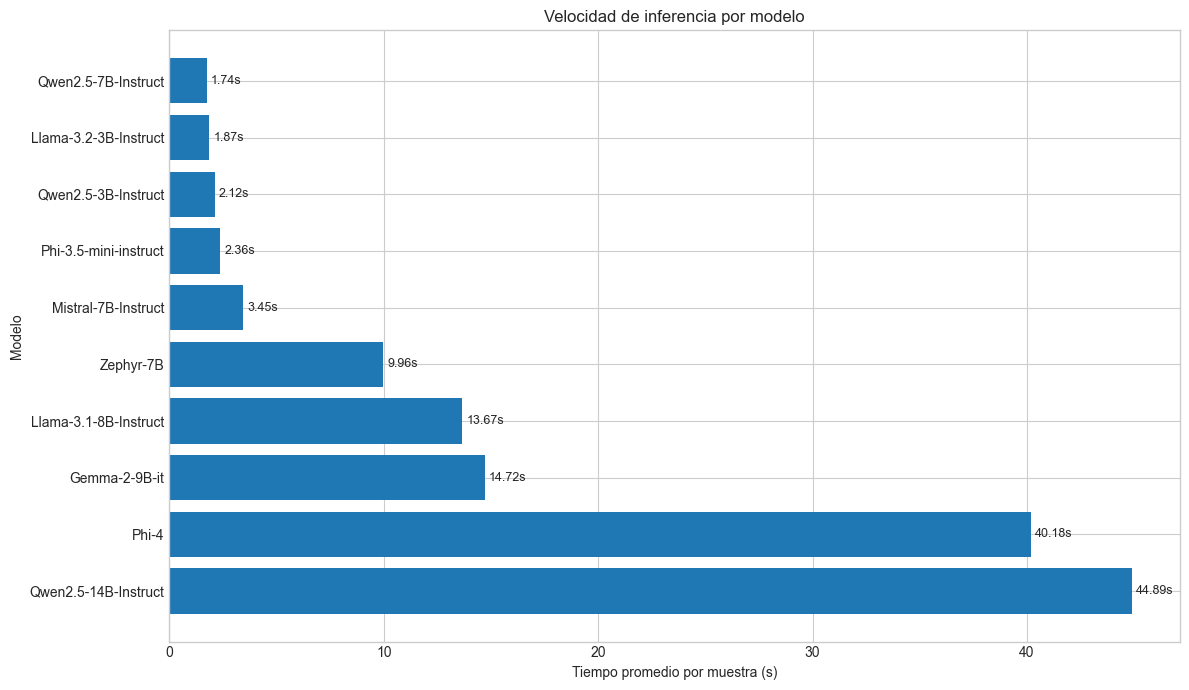

In [ ]:
speed_cols = [
    'model_name',
    'avg_time_per_sample_sin_plan',
    'avg_time_per_sample_con_plan'
 ]
speed_df = compare_view[[c for c in speed_cols if c in compare_view.columns]].copy()
speed_df = speed_df.sort_values('avg_time_per_sample_sin_plan', ascending=False)

y = np.arange(len(speed_df))
h = 0.38

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(y + h/2, speed_df['avg_time_per_sample_sin_plan'], height=h, label='Sin plan', color='#6c7a89')
ax.barh(y - h/2, speed_df['avg_time_per_sample_con_plan'], height=h, label='Con plan', color='#1f77b4')

ax.set_yticks(y)
ax.set_yticklabels(speed_df['model_name'])
ax.set_xlabel('Tiempo promedio por muestra (s)')
ax.set_ylabel('Modelo')
ax.set_title('Comparacion de velocidad por modelo')
ax.legend()

plt.tight_layout()
plt.show()

## Exportar comparacion

In [ ]:
out_csv = Path('generation_results_comparison_plan_vs_no_plan.csv')
compare_view.to_csv(out_csv, index=False)
print(f'Comparacion guardada en: {out_csv}')

Resumen guardado en: generation_results_summary.csv
